In [1]:
#Plant disease detector
#This model is bulit by me for my Village farmers  who lose crops to diseases which they dont identify inculding my father

#Farmers sends a photo in whatsapp, This tool predicts the disease and sends the disease name and treatment for the respective disease
#It higlights the affected area through a heatmap so the farmers identify where the model is looking
#this notebook is only on this model it does not include whatsapp integration

In [2]:
!pip install -U kaggle split-folders gradio -q
#for file handling and data
import os
import pandas as pd
import numpy as np
import shutil

#for training  deep learning model
import tensorflow as tf
print("tensorflow imported sucessfully")

#for image processing and visualization
import cv2
import matplotlib.pyplot as plt
from PIL import Image

#for dataset splitting and app deployement
import splitfolders
print("splitfolders imported sucessfully")# just conforming colab has a litte problem with splitfolders
import gradio as gr

from google.colab import drive

#keras Stuff for building model
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet_v2 import EfficientNetV2B0

#just checking versions so i know nothing broke
print("tensorflow:" , tf.__version__)
print("gradio", gr.__version__)



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.5/111.5 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.6/248.6 kB 17.1 MB/s eta 0:00:00
tensorflow imported sucessfully
splitfolders imported sucessfully
tensorflow: 2.20.0
gradio 6.20.0


In [3]:
drive.mount("/content/drive")

# making all my folders in my drive so i dont lose when my model when colab disconnects
project_dir="/content/drive/MyDrive/PlantDiseaseProject"

if not os.path.exists(project_dir):
    os.makedirs(project_dir)

#folders inside for models,outputs and samples
model_dir="/content/drive/MyDrive/PlantDiseaseProject/models"
output_dir = "/content/drive/MyDrive/PlantDiseaseProject/outputs"
sample_dir = "/content/drive/MyDrive/PlantDiseaseProject/samples"

os.makedirs(model_dir, exist_ok=True)
os.makedirs(output_dir, exist_ok=True)
os.makedirs(sample_dir, exist_ok=True)

# paths to save the model. FINAL one is after all epochs, BEST one is the best score during training
final_model_path = model_dir + "/efficientnetv2_plant_disease_model.keras"
best_model_path = model_dir + "/best_efficientnetv2_plant_disease_model.keras"

print("folders done")


Mounted at /content/drive
folders done


In [4]:
#setting up kaggle so i can download the dataset
#i need the kaggle.json api key file for this  i put mine in drive

kaggle_json_drive = "/content/drive/MyDrive/Kaggle/kaggle.json"
kaggle_json_local = "/root/.kaggle/kaggle.json"

os.makedirs("/root/.kaggle", exist_ok=True)

#copied the file from drive to the localkaggle folder so kaggle can find it
if os.path.exists(kaggle_json_drive):
  shutil.copy(kaggle_json_drive, kaggle_json_local)
  os.chmod(kaggle_json_local,0o600)# kaggle throws a warning if the file isnt 600 permissions, took me a while to figure that out

  print("kaggle.json loaded")
else:
  print("not found")


kaggle.json loaded


In [5]:
# downloading plant village dataset form kaggle
#only downloads when i need it(saves time when i rerun notebook)

raw_data_dir = "/content/plantvillage"
if not os.path.exists(raw_data_dir):
  #unzipping so it extracts automatically or i get a zip and have to unzip it myself
  !kaggle datasets download -d abdallahalidev/plantvillage-dataset -p /content/plantvillage --unzip
  print("dataset downloaded")
else:
  print("data set alrady there skipping downlaoding")

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [00:10<00:00, 215MB/s]

dataset downloaded


In [6]:
#splitting the dataset into three folders train,val,test to prevent data leakage
# i am using colour images(there is also balck and white images and and segmented versions)

source_dir = "/content/plantvillage/plantvillage dataset/color"
split_data_dir = "/content/plantvillage_split"

if not os.path.exists(split_data_dir):
  splitfolders.ratio(
      source_dir,
      output=split_data_dir,
      seed=42,# seed 42 because i get exact result if i rerun anytime
      ratio=(0.70,0.15,0.15),# best to mantain balance
      group_prefix=None,
      move=False

  )
  print("data splitted")
else:
  print("data already splitted")

Copying files: 54305 files [00:11, 4536.85 files/s]

data splitted


In [7]:
img_size=224 #default for efficientnet
batch_size= 32 # Tried 64 but colab gave me OOM error

train_datagen= ImageDataGenerator( #arguementation for training so that it does not memorise image, it creates slightly changed versions of images
    rotation_range=20,
    horizontal_flip=True, # good for images
    zoom_range=0.2
)
# i didnt do arguemention fot val and test because i want my numbers to be honest,arguementing this would make the numbers noisy and unreliable
val_test_datagen=ImageDataGenerator()
#efficientnet has its own rescalling internally so i am not adding rescale=1./255 here

In [8]:
train_gen=train_datagen.flow_from_directory(
    f"{split_data_dir}/train",# if this path is slightly wrong everything breaks
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="categorical",# categorical because i have many classes,would have used binary if i have only two classes
    shuffle=True,#shuffeling because it does not learn the order of folders
    seed=42
)
val_gen= val_test_datagen.flow_from_directory(
    f"{split_data_dir}/val",
    target_size=(img_size,img_size),
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False, # i didnt do true becuase because predictions wont line up with true labels in future
)
test_gen = val_test_datagen.flow_from_directory(
    f"{split_data_dir}/test",
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False # same here
)


Found 37997 images belonging to 38 classes.
Found 8129 images belonging to 38 classes.
Found 8179 images belonging to 38 classes.


In [9]:
# grabbing class count and names from the generator instead of hardcoding them (hardcoding = pain if dataset changes)
num_classes = len(train_gen.class_indices)
class_labels = list(train_gen.class_indices.keys())   # class_indices is a dict like {'Apple_scab': 0, ...}, keys are the names

print("number of classes:", num_classes)
print("train images:", train_gen.samples)
print("val images:", val_gen.samples)
print("test images:", test_gen.samples)
print(class_labels)

number of classes: 38
train images: 37997
val images: 8129
test images: 8179
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_lea

In [ ]:
base_model=EfficientNetV2B0( #loading efficientnetv2 pretrained on imagenet this is the transferlearning part
    weights="imagenet", #imagenet  weights if i put none here i get random weights and transferlearning does not happen
    include_top=False, # false because i have only 38 classes not 1000
    include_preprocessing=True,# handles rescalling on its own thats why i skipped resclae=1./255 earlier
    input_shape=(img_size,img_size,3)# 3 RGB channels must match my image size
)

base_model.trainable=False # this freezes so the weights dont change during training


In [ ]:
#building my own model on top of frozen base
inputs = layers.Input(shape=(img_size, img_size, 3))
x = base_model(inputs, training=False)   # training is false becuase it keeps batchnorm layers frozen it matters when base is frozen
x = layers.GlobalAveragePooling2D()(x)   # this flattens the features i used this instead of Flatten because it cretes million of extra parameters and and overfits
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)   # dropout to prevent overfitting 0.3  drop 30 percent.too high 0.8 and it wont learn anything and 0.0 it overfits
outputs = layers.Dense(num_classes, activation="softmax", name="Plant_Disease_Output")(x)   # i used soft max because its 38 classes, would have used sigmoid if its only 2 classes

model = models.Model(inputs, outputs)

In [ ]:
model.compile(
    optimizer="adam", #using this string becuase i forgot to imprt adam at starting.learning rate is default anyways0.001
    loss="categorical_crossentropy",# my labels are one-hot (like this [0,0,1,0..]) so i used this one. if labels were plain numbers like this one (0,1,2..) would have used  sparse_categorical_crossentropy instead
    metrics=["accuracy"]
)
model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Plant_Disease_Output (Dense)    │ (None, 38)             │        48,678 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,973,110 (22.79 MB)

 Trainable params: 51,238 (200.15 KB)

 Non-trainable params: 5,921,872 (22.59 MB)

In [ ]:
#now just a small smoke test before real training starts
#just running 1 epoch on few batches so i can know nothing crashes and loss moves
smoke=model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=1,steps_per_epoch=5, #kept only 5 keeps it fast
    validation_steps=3 # just 3 dont need full thing for testing
)

5/5 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.0625 - loss: 4.4292 - val_accuracy: 0.0312 - val_loss: 3.3129


In [ ]:
# hit an error on smoke test

print ("img_size :", img_size)
images ,labels=next(train_gen)
print("image shape :",images.shape)
print("model:",model.input_shape)

img_size : 224
image shape : (32, 224, 224, 3)
model: (None, 224, 224, 3)


In [ ]:
# found an error in val_gen which caused error in imgsize and fixed it now\
# now the actual traning part with callbacks
# using callbacks becuase they help in saving time and runs automaticall when training is happening
# this stops training if val_loss stops improving so i dont waste time improving
phase1_callbacks=[
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint( # this saves the best model to drive so i dont lose when colab disconnects it happend to me many times
        filepath=best_model_path,
        monitor="val_accuracy", # this is for saving based on best accuracy
        save_best_only=True, # this is only saves best
        verbose=1
    )
]

In [ ]:
# now the actual training part
history= model.fit(
    train_gen,
    epochs=10,# 10 epochs is plenty for phase 1 ,phase 2 is fine tuning
    validation_data=val_gen,
    callbacks=phase1_callbacks,
    verbose=1

)

Epoch 1/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.7522 - loss: 0.8908
Epoch 1: val_accuracy improved from None to 0.94969, saving model to /content/drive/MyDrive/PlantDiseaseProject/models/best_efficientnetv2_plant_disease_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/PlantDiseaseProject/models/best_efficientnetv2_plant_disease_model.keras
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 520s 438ms/step - accuracy: 0.8544 - loss: 0.4922 - val_accuracy: 0.9497 - val_loss: 0.1621
Epoch 2/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.9276 - loss: 0.2323
Epoch 2: val_accuracy improved from 0.94969 to 0.95940, saving model to /content/drive/MyDrive/PlantDiseaseProject/models/best_efficientnetv2_plant_disease_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/PlantDiseaseProject/models/best_efficientnetv2_plant_disease_model.keras
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 486s 409ms/step - accuracy: 0.9284 - loss: 0.2284 - val_accuracy: 0.959

In [ ]:
# 96.9 accuracy looks good now lets see the real accuracy by testing on test set
test_loss,test_acc=model.evaluate(test_gen,verbose=1)
print(f"test accuaracy :{test_acc:.4f}")
print(f"test loss:{test_loss:.4f}")

256/256 ━━━━━━━━━━━━━━━━━━━━ 24s 95ms/step - accuracy: 0.9724 - loss: 0.0857
test accuaracy :0.9724
test loss:0.0857


In [ ]:
# saving the training history to a csv
phase1_history_df = pd.DataFrame(history.history)
phase1_history_df.index = phase1_history_df.index + 1
phase1_history_df.to_csv(f"{output_dir}/phase1_history.csv", index_label="epoch")
phase1_history_df   # just showing it so i can see the table right here in colab

,accuracy,loss,val_accuracy,val_loss
1,0.854357,0.492156,0.949686,0.162086
2,0.928389,0.228376,0.959405,0.133128
3,0.935653,0.200794,0.957313,0.132691
4,0.939811,0.187749,0.963218,0.113138
5,0.940732,0.188502,0.969123,0.097215
6,0.944864,0.172365,0.956452,0.139941
7,0.945259,0.178020,0.962234,0.115637
8,0.947285,0.168619,0.963095,0.118961
9,0.946733,0.172762,0.965309,0.111349


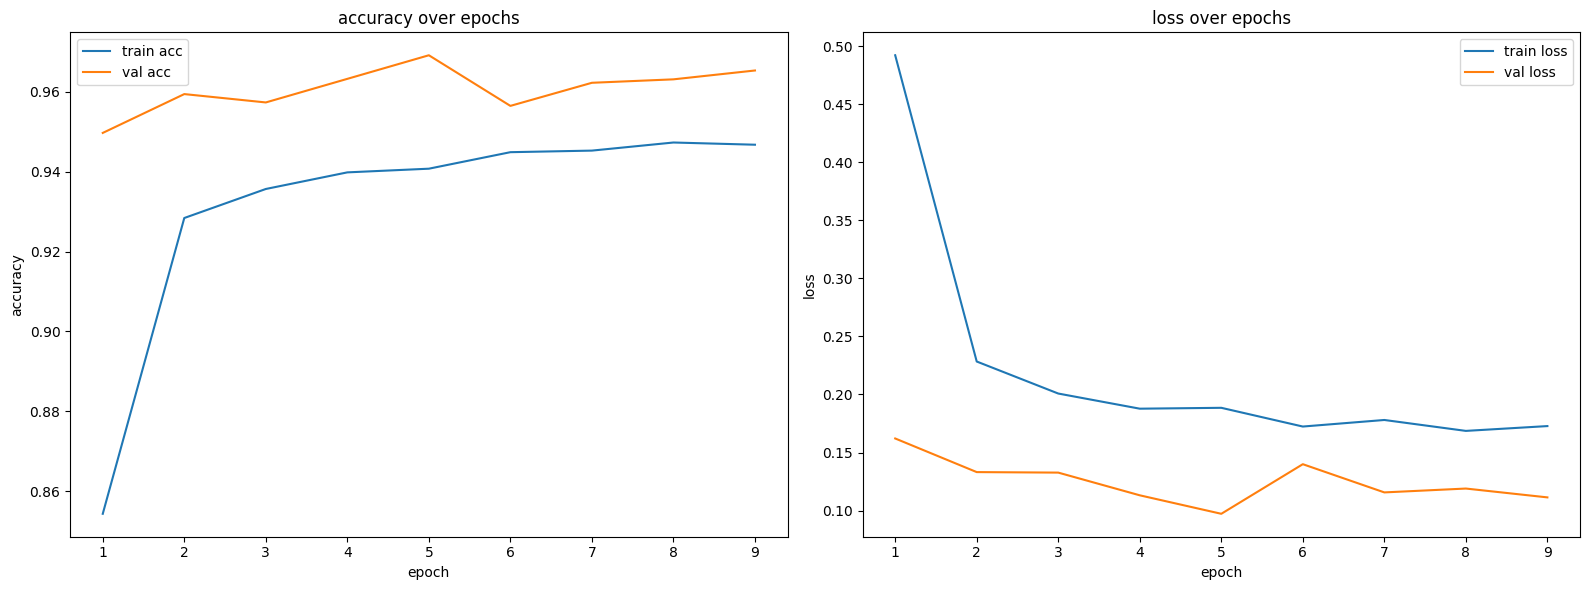

In [ ]:
#97.24 on test accuracy.now the fun part of where my model does good and where it does not
#1 plotting accuracyand loss over the epochs so i can see how trainng went
plt.figure(figsize=(16,6))

#accuaracy plot on left
plt.subplot(1,2,1)
plt.plot(phase1_history_df["accuracy"],label="train acc")
plt.plot(phase1_history_df["val_accuracy"],label="val acc")
plt.title("accuracy over epochs")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()

#loss plot on right
plt.subplot(1,2,2)
plt.plot(phase1_history_df["loss"], label="train loss")
plt.plot(phase1_history_df["val_loss"], label="val loss")
plt.title("loss over epochs")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()

plt.tight_layout() #this stops the two plots from overlapping each other
plt.savefig(f"{output_dir}/phase1_curves.png")#saving the figure so i can put it in my report
plt.show()

In [13]:
#session reset i am loading my model now
model=tf.keras.models.load_model(best_model_path)
print("model is loaded")
print("model input:",model.input_shape)

model is loaded
model input: (None, 224, 224, 3)


In [18]:
#now confusion metrics
from sklearn.metrics import classification_report, confusion_matrix #sklearn has the metrics keras does not do these
import seaborn as sns #for the heatamp

test_gen.reset()#should reset our generator first or our whole matrix will be wrong
pred_probs=model.predict(test_gen,verbose=1)
y_pred=np.argmax(pred_probs,axis=1)#this grabs the class with highest probability
y_true=test_gen.classes
print("predictions shape:", pred_probs.shape)

256/256 ━━━━━━━━━━━━━━━━━━━━ 16s 62ms/step
predictions shape: (8179, 38)


In [19]:
#now lets see at which diseases my  model  is bad at
report = classification_report(y_true, y_pred, target_names=class_labels)
print(report)

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.94      0.89      0.92        95
                                 Apple___Black_rot       1.00      0.99      0.99        94
                          Apple___Cedar_apple_rust       0.98      1.00      0.99        42
                                   Apple___healthy       0.96      1.00      0.98       248
                               Blueberry___healthy       1.00      1.00      1.00       226
          Cherry_(including_sour)___Powdery_mildew       1.00      0.99      1.00       159
                 Cherry_(including_sour)___healthy       0.99      0.99      0.99       129
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.90      0.77      0.83        78
                       Corn_(maize)___Common_rust_       0.99      1.00      0.99       180
               Corn_(maize)___Northern_Leaf_Blight       0.89      0.95      0.

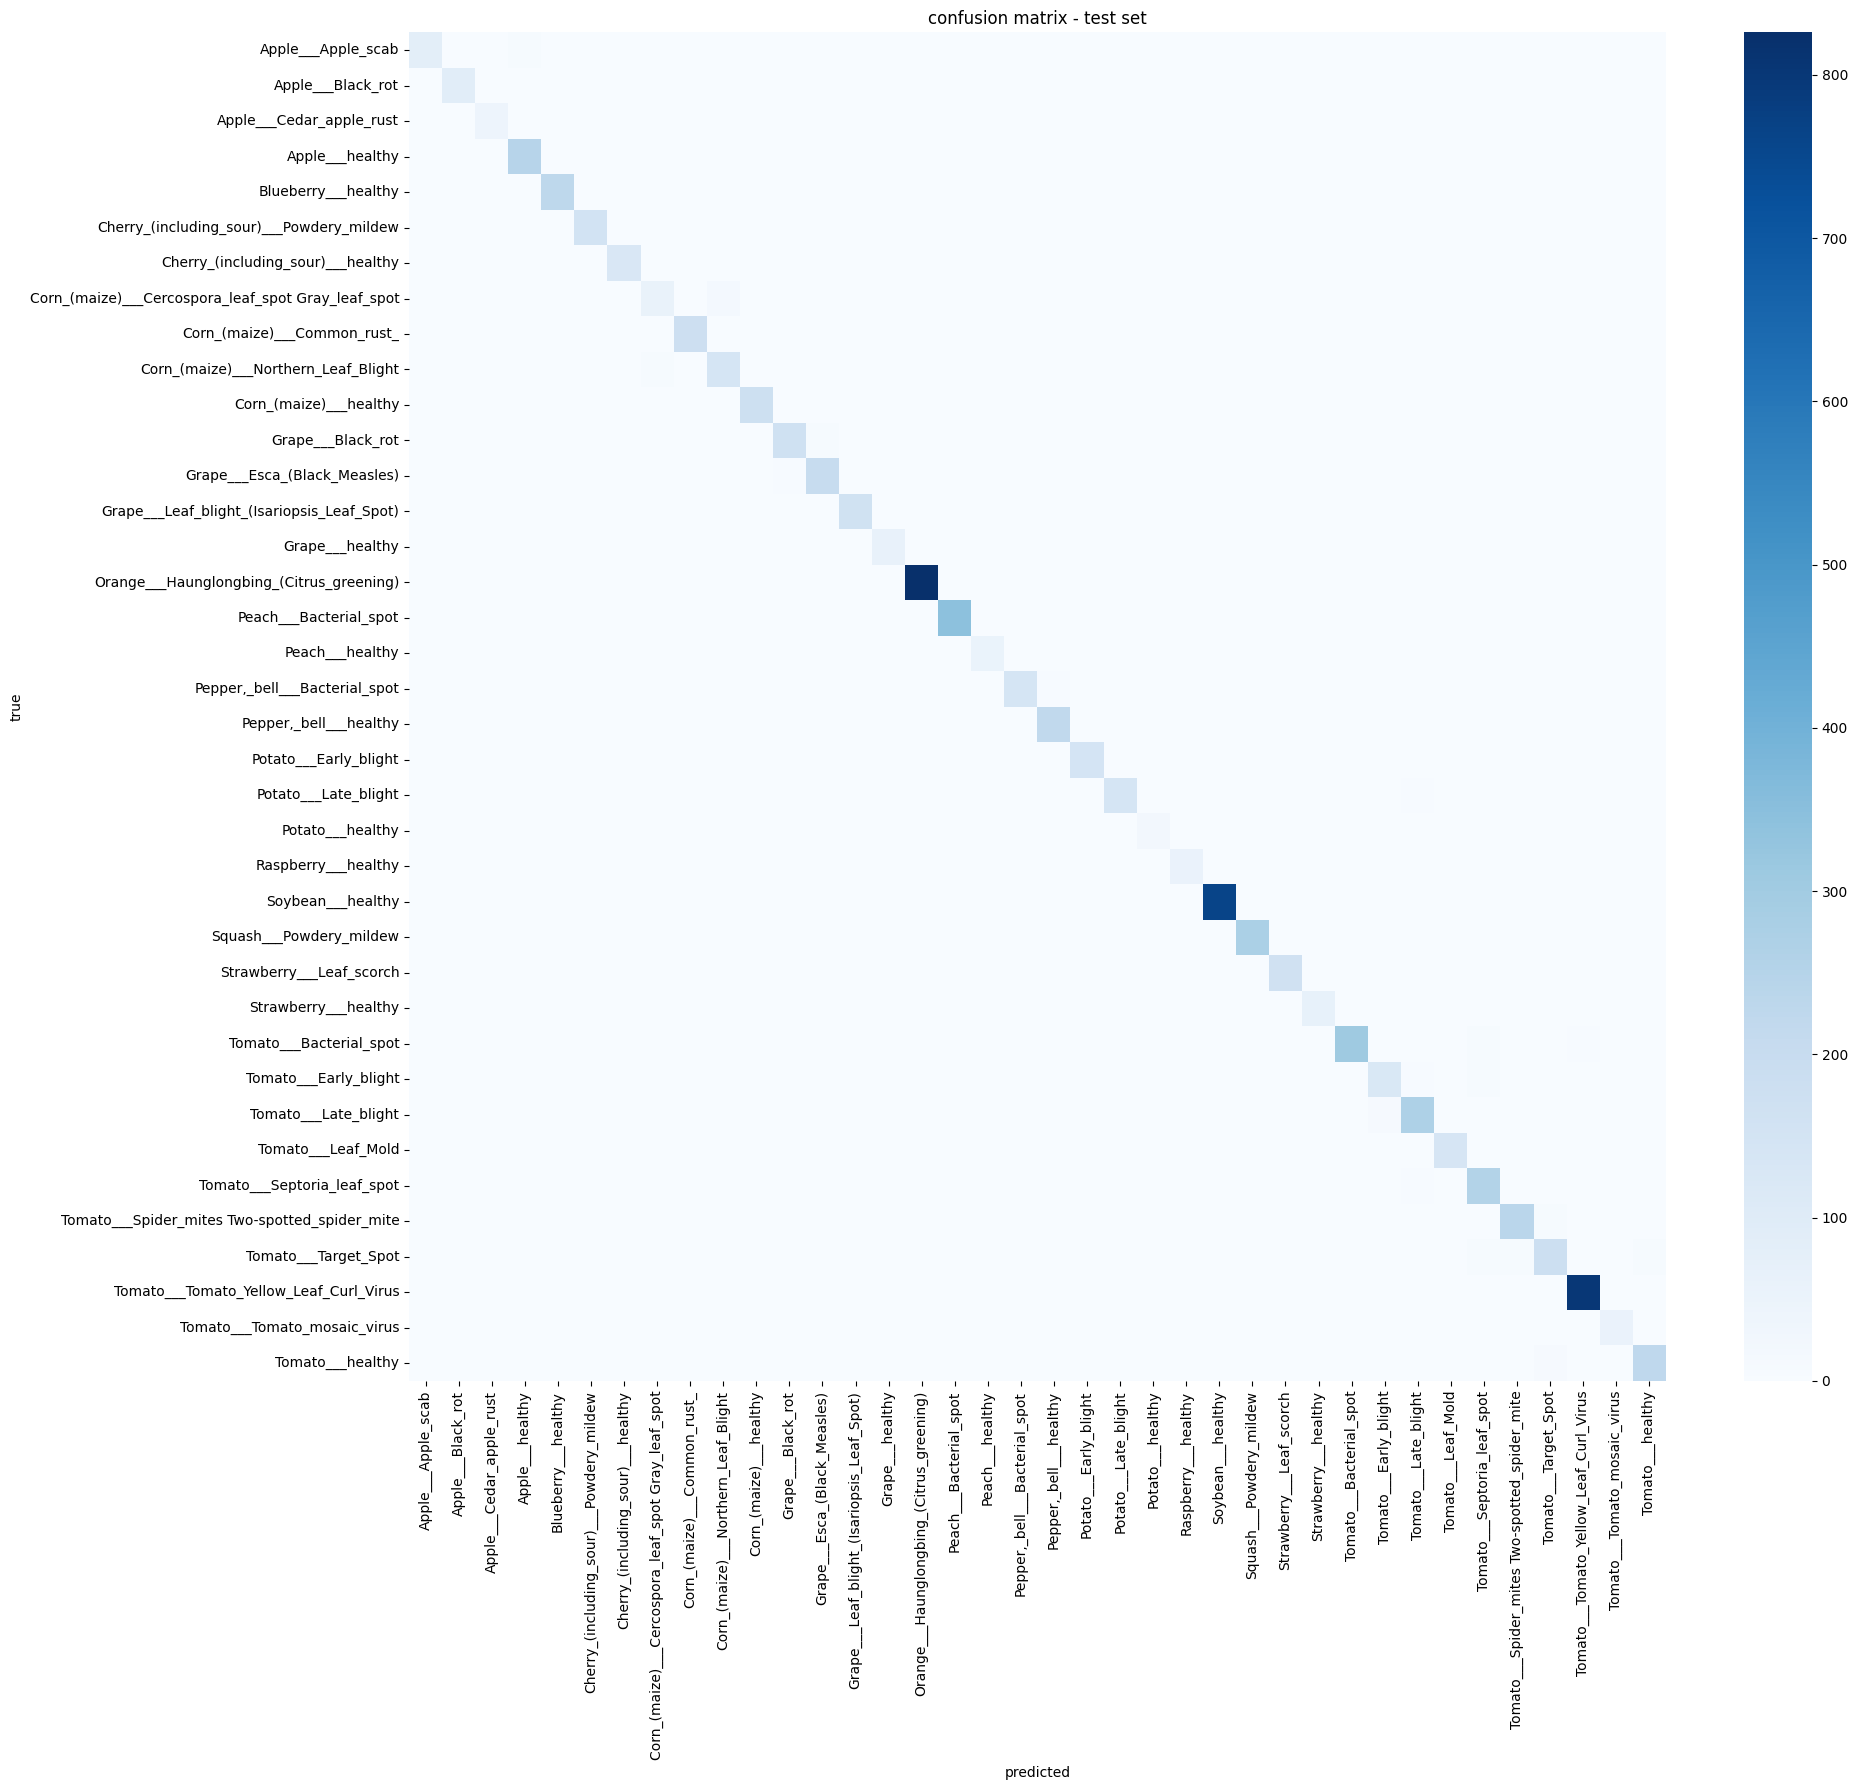

In [20]:
# now the actual part
#rows are true disease and columns are what the model has guessed
cm=confusion_matrix(y_true,y_pred)

plt.figure(figsize=(20, 18))# i kept this huge on purpose
sns.heatmap(cm,annot=False,cmap="Blues",xticklabels=class_labels,yticklabels=class_labels)
#i kept annot false because putting numbers in all 38x38 boxes is a cluttered mess the color does the job
plt.title("confusion matrix - test set")
plt.xlabel("predicted")
plt.ylabel("true")
plt.tight_layout()# this keeps the long class names from getting cut off
plt.savefig(f"{output_dir}/confusion_matrix.png")
plt.show()

In [23]:
#now phase 2 Finetuning now i unfreeze the top layers of the base so it lerans the plant specific features not just generic imagenet ones
base_model=model.get_layer("efficientnetv2-b0")# this grabs  the base out of the loaded model, my base model variable died when the session reset
base_model.trainable #this unfrezzes it

for layer in base_model.layers[:-30]: #only the last 30 layers early layers just detects edges and colours
  layer.trainable=False

for layer in base_model.layers: # i kept the batchnorm frozen in the forzen base becuase it messes the pretrained stats and tanks the accuracy
    if isinstance(layer,layers.BatchNormalization):
        layer.trainable =False

print("trainable layers in base now:",sum(l.trainable for l in base_model.layers))


trainable layers in base now: 0


In [26]:
#ok so the cell above didnt actually work base_model.trainable=True doesnt cascade to the inner layers after load model (weird keras thing, took forever to figure that out)
#so im doing it the reliable way by setting it every layer EXPLICITLY instead of trusting the container flag
#now  freezing the whole base first, clean slate
for layer in base_model.layers:
    layer.trainable =False
# now unfreezing just the last 20 layers but skipping batchnorm again
for layer in base_model.layers[-20:]:
    if not isinstance(layer, layers.BatchNormalization):
        layer.trainable = True
#now double checking if it actually worked this time it should be 16 layers and  all conv/activation and no batchnorm
trainable_layers = [l.name for l in base_model.layers if l.trainable]
print("num trainable:", len(trainable_layers))
print(trainable_layers)

num trainable: 16
['block6g_drop', 'block6g_add', 'block6h_expand_conv', 'block6h_expand_activation', 'block6h_dwconv2', 'block6h_activation', 'block6h_se_squeeze', 'block6h_se_reshape', 'block6h_se_reduce', 'block6h_se_expand', 'block6h_se_excite', 'block6h_project_conv', 'block6h_drop', 'block6h_add', 'top_conv', 'top_activation']


In [27]:
# Now recompling because i changed trainable  (heard this as #1 fine-tuning mistake that  everyone forgets this)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),# its super tiny lr (1e-5) because a normal one would nuke the pretrained weightsand full path cause i never imported Adam
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [44]:
#now finally the actaul fine-tuning part.saving phase 2 to final_model_path so my good phase 1 model stays safe in best_model_path (in case this makes it worse)
fine_tune_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,#keeping smaller patience than phase 1 beacuase  fine-tuning converges fast and i dont wanna let it overfit
        restore_best_weights=True,# keeping the best epochs weights not the last ones
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=final_model_path,# saving to the final path this time
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]

fine_tune_history =model.fit(
    train_gen,
    epochs=5,#i took way fewer epochs because finetuning doesnt need many
    validation_data=val_gen,
    callbacks=fine_tune_callbacks,
    verbose=1
)
#thats it for today will do traning tommorrow

Epoch 1/5


KeyboardInterrupt: 